In [63]:
#1. 라이브러리 설치
def read_library():

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import scipy.stats as stats
    import statsmodels.formula.api as smf
    import statsmodels.api as sm
    import platform
    import ast

    pd.set_option("display.float_format", "{:.2f}".format)

    if platform.system() == "Darwin":
        plt.rcParams["font.family"] = "AppleGothic"
    elif platform.system() == "Windows":
        plt.rcParams["font.family"] = "Malgun Gothic"
    else:
        plt.rcParams["font.family"] = "NanumGothic"

    return pd, np, plt, sns, stats, smf, sm, ast

#2. 데이터 로드

def load_data(pd):

    df = pd.read_csv("../원본 데이터 셋/2025_Airbnb_NYC_listings.csv")

    print("데이터 크기:", df.shape)
    print(df.head())

    return df

#3. 데이터 확인
def overview(df):

    print(df.info())
    print(df.describe())


#4. 가짜 결측 확인
def fake_null(df):

    fake_null = ['NaN','None','none','NULL','null','N/A','na','']

    fake_counts = df.isin(fake_null).sum()

    print(fake_counts[fake_counts > 0])


#5. Datetime 변환
def datetime(df, pd):

    date_cols = [
        "host_since",
        "first_review",
        "last_review",
        "calendar_last_scraped"
    ]

    df[date_cols] = df[date_cols].apply(pd.to_datetime, errors="coerce")

    return df


#6. 가격 컬럼 전처리
def price_clean(df, np):

    df["price"] = (
        df["price"]
        .astype(str)
        .str.replace("$","",regex=False)
        .str.replace(",","",regex=False)
        .astype(float)
    )

    df["price_log"] = np.log1p(df["price"])

    return df


#7. 리뷰관련 컬럼 결측치 처리
def missing(df):

    review_cols = [
        "number_of_reviews",
        "number_of_reviews_ltm",
        "number_of_reviews_l30d",
        "reviews_per_month",
        "estimated_occupancy_l365d"
    ]

    df[review_cols] = df[review_cols].fillna(0)

    df["review_scores_rating"] = df["review_scores_rating"].fillna(
        df["review_scores_rating"].median()
    )

    df["bathrooms"] = df["bathrooms"].fillna(0)
    df["bedrooms"] = df["bedrooms"].fillna(0)
    df["beds"] = df["beds"].fillna(0)

    return df


#8. 파생컬럼 생성
def feature_engineering(df, np):

    df["room_capacity"] = (
        df["bathrooms"] +
        df["bedrooms"] +
        df["beds"]
    )

    df["occupancy_rate"] = (
        df["estimated_occupancy_l365d"] / 365
    )

    df["log_reviews"] = np.log1p(df["number_of_reviews"])

    return df


# 9. Amenities Count(편의시설 길이 세는 함수)
def amenity_count(x):
    try:
        return len(ast.literal_eval(x))
    except:
        return 0

df["amenities_len"] = df["amenities"].apply(amenity_count)


#10. 룸타입 맵핑
def step10_regulation(df):

    property_map = {

        "Room in hotel": "Lodging",
        "Room in boutique hotel": "Lodging",

        "Entire rental unit": "Residential",
        "Private room in rental unit": "Residential",
        "Private room in home": "Residential",
        "Entire home": "Residential",
        "Entire condo": "Residential"
    }

    df["property_regulation_type"] = (
        df["property_type"]
        .map(property_map)
        .fillna("Other")
    )

    return df



# 11. 규제 범위 나누기
def step11_legal_filter(df):

    df["legal_flag"] = "Legal"

    df.loc[
        (df["property_regulation_type"]=="Residential") &
        (df["room_type"]=="Entire home/apt") &
        (df["minimum_nights"] < 30),
        "legal_flag"
    ] = "Illegal"

    df = df[
        ((df['property_regulation_type'] == 'Residential') & (df['legal_flag'] == 'Legal'))
        | (df['property_regulation_type'] == 'Lodging')
    ]

    return df


# 12. Strategy Classification
def strategy(row):

    if row["property_regulation_type"]=="Residential":

        if row["minimum_nights"] < 30:
            return "Residential_short_term"
        else:
            return "Residential_long_term"

    else:
        return "Hotel"

df["rental_strategy"] = df.apply(strategy, axis=1)


# 13. 매출 공식 검증
def revenue_verification(df):

    df["calc_revenue"] = (
        df["price"] *
        df["estimated_occupancy_l365d"]
    )

    print(
        "Revenue match:",
        (df["calc_revenue"]==df["estimated_revenue_l365d"]).mean()
    )

    return df


# 14. Outlier 제거해보고 확인
def outlier_check(df):

    df_example = df[df["price"] < 1000].copy()

    return df_example


# 15. Price Distribution
def price_distribution(df_example, sns, plt):

    sns.histplot(df_example["price"], bins=50)
    plt.title("Price Distribution")
    plt.show()


    sns.countplot(data=df_example, x="neighbourhood_group_cleansed")
    plt.title("Listing Count by Borough")
    plt.show()


# 16. Demand Analysis
def demand_analysis(df, sns, plt):

    sns.scatterplot(
        data=df,
        x="price",
        y="occupancy_rate",
        alpha=0.4
    )
    plt.title("Price vs Occupancy")
    plt.show()


    sns.scatterplot(
        data=df,
        x="number_of_reviews",
        y="occupancy_rate"
    )
    plt.title("Reviews vs Occupancy")
    plt.show()


# 17. Availability Analysis
def availability_analysis(df, sns, plt):

    sns.boxplot(
        data=df,
        x="availability_365",
        y="price"
    )
    plt.title("Availability vs Price")
    plt.show()


# 18. Price Quantile Strategy
def price_quantile(df, pd):

    df["price_q"] = pd.qcut(df["price"],4)

    print(
    df.groupby("price_q")[
    ["occupancy_rate","estimated_revenue_l365d"]
    ].median()
    )

    return df


# 19. Revenue 0 Listing
def zero_revenue(df):

    zero_ratio = (
        df["estimated_revenue_l365d"]==0
    ).mean()

    print("Revenue zero ratio:",zero_ratio)


# 20. Spearman Correlation
def spearman(df, stats):

    corr, p = stats.spearmanr(
        df["price"],
        df["occupancy_rate"]
    )

    print("Spearman:", corr)
    print("p:", p)


# 21. Kruskal Test
def kruskal(df, stats):

    groups = [

    df[df["rental_strategy"]=="Residential_long_term"]
    ["estimated_revenue_l365d"],

    df[df["rental_strategy"]=="Residential_short_term"]
    ["estimated_revenue_l365d"],

    df[df["rental_strategy"]=="Hotel"]
    ["estimated_revenue_l365d"]

    ]

    print(stats.kruskal(*groups))


# 22. ANOVA
def anova(df, smf, sm):

    anova_model = smf.ols(

    "estimated_revenue_l365d ~ C(rental_strategy)",

    data=df

    ).fit()

    print(sm.stats.anova_lm(anova_model))


# 23. Regression
def regression(df, smf):

    model = smf.ols(

    """
    occupancy_rate ~

    price_log
    + log_reviews
    + review_scores_rating
    + accommodates
    + minimum_nights
    + amenities_len
    """

    ,data=df

    ).fit()

    print(model.summary())

    return model


# 24. Regression Visualization
def regression_viz(model, plt):

    coef = model.params.drop("Intercept")

    coef.sort_values().plot(
    kind="barh",
    figsize=(8,6)
    )

    plt.title("Occupancy Drivers")
    plt.show()


# 25. Market Heatmap
def market_heatmap(df, sns, plt):

    heat = df.pivot_table(

    values="estimated_revenue_l365d",
    index="neighbourhood_group_cleansed",
    columns="room_type",
    aggfunc="median"

    )

    sns.heatmap(
    heat,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
    )

    plt.title("Revenue Heatmap")
    plt.show()


# 26. Investment Simulator
def recommend_investor(df, persona, initial_investment, top_n=10):

    # ---------------------------------------------------------
    # 1. 페르소나 조건 필터링
    # ---------------------------------------------------------

    filtered = df[
        (df['rental_strategy'] == persona['rental_strategy']) &
        (df['neighbourhood_group_cleansed'] == persona['neighbourhood_group_cleansed']) &
        (df['room_type'] == persona['room_type'])
    ]

    if filtered.empty:
        print("조건에 맞는 데이터가 없습니다. 조건을 다시 입력하세요.")
        return pd.DataFrame()

    # ---------------------------------------------------------
    # revenue = 0 인 listing 제거
    # 예약이 없거나 추정 실패한 숙소는 0으로 기록되기 때문
    # ---------------------------------------------------------

    filtered = filtered[
        filtered["estimated_revenue_l365d"] > 0
    ]

    if filtered.empty:
        print("매출 데이터가 있는 숙소가 없습니다.")
        return pd.DataFrame()

    # ---------------------------------------------------------
    # 2. 세그먼트별 성과 지표 계산
    # ---------------------------------------------------------

    segment_summary = filtered.groupby(
        ['room_type', 'accommodates']
    ).agg(

        median_price=('price', 'median'),
        median_occupancy_rate=('occupancy_rate', 'median'),

        # 연매출 중앙값
        median_revenue=('estimated_revenue_l365d', 'median'),

        # 세그먼트 총매출
        총매출=('estimated_revenue_l365d', 'sum'),

        # 경쟁 숙소 수
        listing_count=('price', 'count'),

        median_reviews=('number_of_reviews', 'median')

    ).reset_index()

    # ---------------------------------------------------------
    # 표본 안정성 필터
    # ---------------------------------------------------------

    segment_summary = segment_summary[
        segment_summary['listing_count'] >= 50
    ]

    if segment_summary.empty:
        print("표본수 50개 이상인 세그먼트가 없습니다.")
        return pd.DataFrame()

    # ---------------------------------------------------------
    # 3. 경쟁 대비 수익 효율 계산
    # ---------------------------------------------------------

    전체매물수 = segment_summary['listing_count'].sum()
    전체매출 = segment_summary['총매출'].sum()

    # 매물 비중
    segment_summary['매물비중'] = (
        segment_summary['listing_count'] / 전체매물수
    )

    # 매출 비중
    segment_summary['매출비중'] = (
        segment_summary['총매출'] / 전체매출
    )

    # 경쟁 대비 수익 효율 지수
    segment_summary['수익효율지수'] = (
        segment_summary['매출비중'] /
        segment_summary['매물비중']
    )

    # ---------------------------------------------------------
    # 4. 시장 포지션 분류 (4분면)
    # ---------------------------------------------------------

    경쟁기준 = segment_summary['listing_count'].median()

    def 시장분류(row):

        경쟁높음 = row['listing_count'] >= 경쟁기준
        효율높음 = row['수익효율지수'] >= 1

        if (not 경쟁높음) and 효율높음:
            return "블루오션"

        elif 경쟁높음 and 효율높음:
            return "레드오션(Mainstream)"

        elif 경쟁높음 and (not 효율높음):
            return "헬오션(Avoid)"

        else:
            return "저수요 틈새시장"

    segment_summary['시장포지션'] = segment_summary.apply(시장분류, axis=1)

    # ---------------------------------------------------------
    # 5. 수익 계산
    # estimated_revenue_l365d = 연매출 추정치
    # ---------------------------------------------------------

    segment_summary['추정 월 매출'] = (
        segment_summary['median_revenue'] / 12
    )

    # 운영/관리 비용 (보수적으로 25%)
    segment_summary['추정 관리/유지비'] = (
        segment_summary['추정 월 매출'] * 0.25
    )

    segment_summary['추정 월 이익'] = (
        segment_summary['추정 월 매출'] -
        segment_summary['추정 관리/유지비']
    )

    # ---------------------------------------------------------
    # 6. 투자금 회수기간 계산
    # ---------------------------------------------------------

    segment_summary['추정 회수기간(월)'] = np.where(
        segment_summary['추정 월 이익'] > 0,
        initial_investment / segment_summary['추정 월 이익'],
        np.nan
    )

    # ---------------------------------------------------------
    # 7. 투자 매력도 점수
    # ---------------------------------------------------------

    segment_summary['투자매력도점수'] = (
        segment_summary['수익효율지수'] *
        segment_summary['추정 월 이익']
    )

    # ---------------------------------------------------------
    # 8. 투자 추천 TOP N
    # ---------------------------------------------------------

    top_segments = segment_summary.sort_values(
        by='투자매력도점수',
        ascending=False
    ).head(top_n)

    return top_segments


# ---------------------------------------------------------
# 실행 코드
# ---------------------------------------------------------

persona = create_persona()

initial_investment = int(input("초기 투자금 입력 ($): "))

result = recommend_investor(df, persona, initial_investment, top_n=10)

result


=== 투자자 페르소나 입력 ===


,room_type,accommodates,median_price,median_occupancy_rate,median_revenue,총매출,listing_count,median_reviews,매물비중,매출비중,수익효율지수,시장포지션,추정 월 매출,추정 관리/유지비,추정 월 이익,추정 회수기간(월),투자매력도점수
1,Private room,2,96.00,0.70,22890.00,6420263.00,279,64.00,0.84,0.88,1.05,레드오션(Mainstream),1907.50,476.88,1430.62,10.48,1497.02
0,Private room,1,74.50,0.70,17085.00,858813.00,52,62.00,0.16,0.12,0.75,저수요 틈새시장,1423.75,355.94,1067.81,14.05,801.94


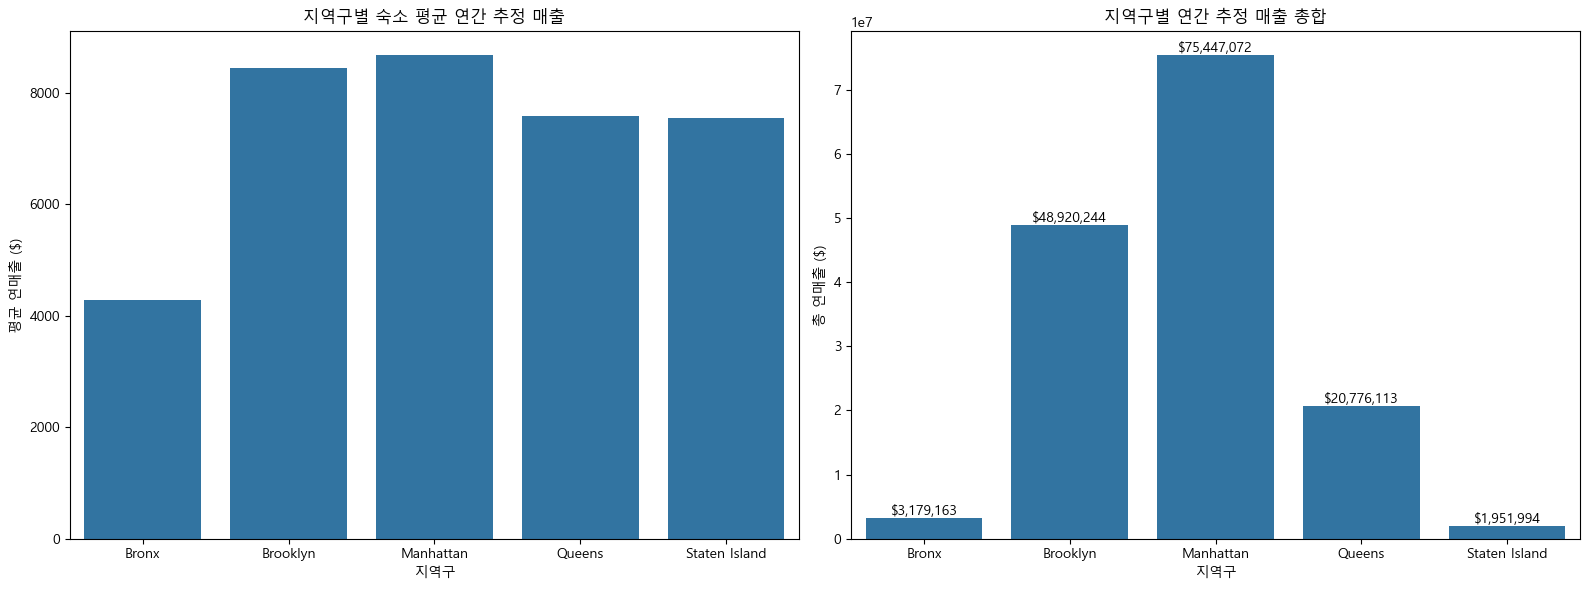

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# 지역구별 매출 집계
revenue_summary = df.groupby("neighbourhood_group_cleansed").agg(
    평균_연매출=("estimated_revenue_l365d", "mean"),
    총_연매출=("estimated_revenue_l365d", "sum"),
    숙소수=("estimated_revenue_l365d", "count")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16,6))


# 1️⃣ 평균 연매출 그래프
sns.barplot(
    data=revenue_summary,
    x="neighbourhood_group_cleansed",
    y="평균_연매출",
    ax=axes[0]
)

axes[0].set_title("지역구별 숙소 평균 연간 추정 매출")
axes[0].set_xlabel("지역구")
axes[0].set_ylabel("평균 연매출 ($)")


# 2️⃣ 총 연매출 그래프
sns.barplot(
    data=revenue_summary,
    x="neighbourhood_group_cleansed",
    y="총_연매출",
    ax=axes[1]
)

axes[1].set_title("지역구별 연간 추정 매출 총합")
axes[1].set_xlabel("지역구")
axes[1].set_ylabel("총 연매출 ($)")


# 🔹 바 위에 $ + 천단위 콤마 표시
for p in axes[1].patches:
    value = p.get_height()
    axes[1].text(
        p.get_x() + p.get_width()/2,
        value,
        f"${value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

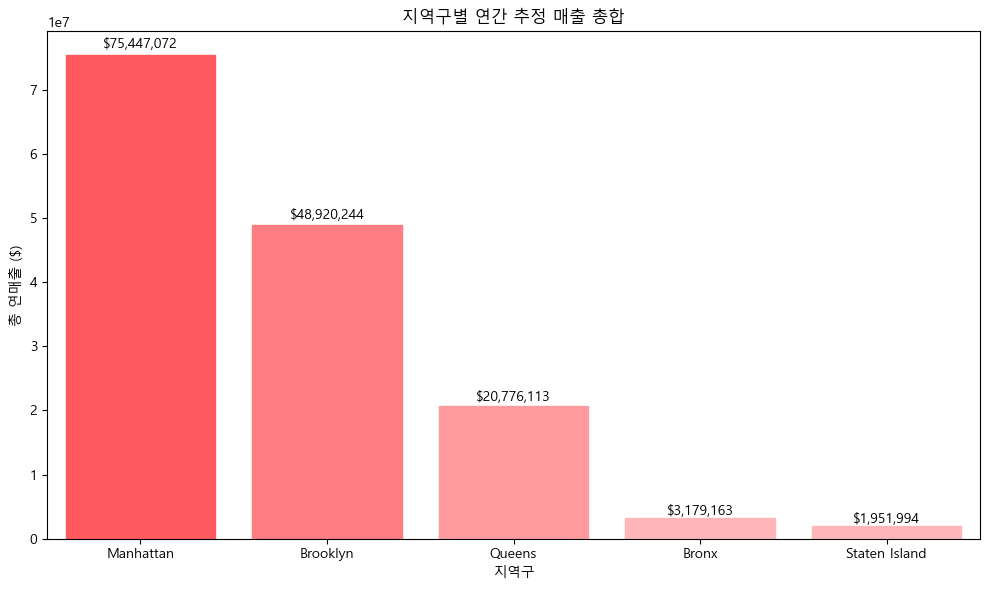

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# 지역구별 총 연매출 계산
revenue_sum = (
    df.groupby("neighbourhood_group_cleansed")["estimated_revenue_l365d"]
    .sum()
    .reset_index()
)

# 매출 기준 내림차순 정렬
revenue_sum = revenue_sum.sort_values(
    by="estimated_revenue_l365d",
    ascending=False
).reset_index(drop=True)

plt.figure(figsize=(10,6))

# 그래프 생성
ax = sns.barplot(
    data=revenue_sum,
    x="neighbourhood_group_cleansed",
    y="estimated_revenue_l365d",
    color="lightgrey"
)

# 지정 색상 (진 → 연)
colors = ["#FF5A5F", "#FF7E82", "#FF9B9E", "#FFB7BA"]

bars = ax.patches

# 색 적용 (데이터 개수와 맞게)
for i in range(len(bars)):
    bars[i].set_color(colors[min(i, len(colors)-1)])

plt.title("지역구별 연간 추정 매출 총합")
plt.xlabel("지역구")
plt.ylabel("총 연매출 ($)")

# 바 위 숫자 표시 ($ + 천단위 콤마)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height * 1.01,  # bar 바로 위
        f"${height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

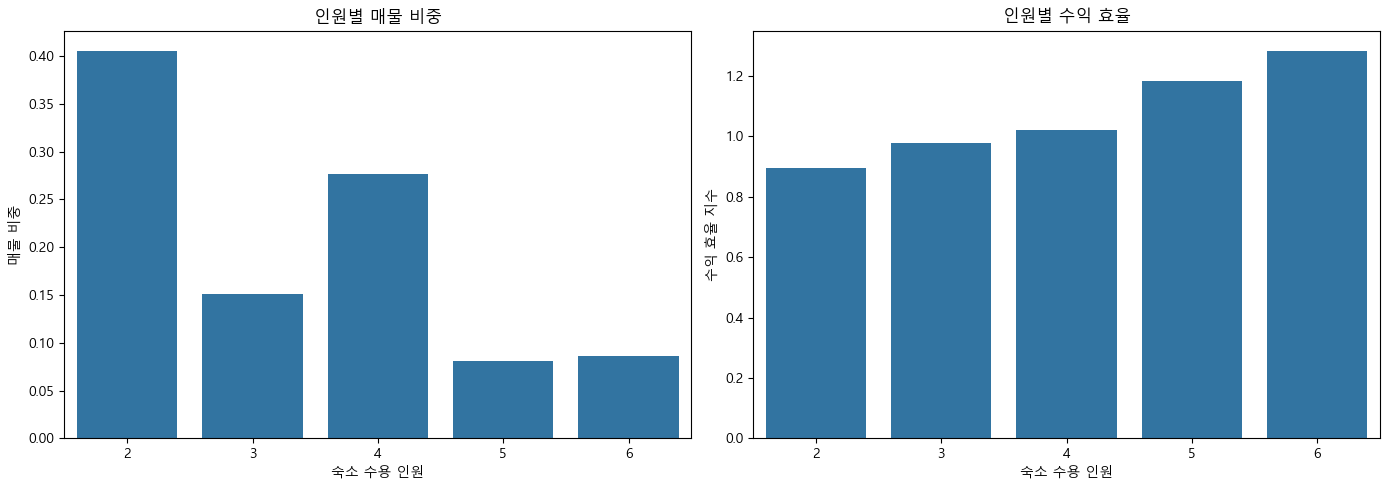

In [57]:
segment_summary = result.copy()

# 그래프 2개 한 화면에 배치
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# -----------------------------
# 1. 인원별 매물 비중
# -----------------------------
sns.barplot(
    data=segment_summary,
    x='accommodates',
    y='매물비중',
    ax=axes[0]
)

axes[0].set_title("인원별 매물 비중")
axes[0].set_xlabel("숙소 수용 인원")
axes[0].set_ylabel("매물 비중")

# -----------------------------
# 2. 인원별 수익 효율
# -----------------------------
sns.barplot(
    data=segment_summary,
    x='accommodates',
    y='수익효율지수',
    ax=axes[1]
)

axes[1].set_title("인원별 수익 효율")
axes[1].set_xlabel("숙소 수용 인원")
axes[1].set_ylabel("수익 효율 지수")

plt.tight_layout()
plt.show()

# 예시 시나리오
| 항목 | 시나리오 1: 브루클린 | 시나리오 2: 맨해튼 | 시나리오 3: 퀸즈 (최적안) |
|-----|------------------|------------------|------------------|
| 페르소나 | 단체 손님 전문 펜션지기 | 리스크 관리 전략가 | 3개월 컷 프로 부업러 |
| 투자 원금 | $25,000 (약 3,300만 원) | $30,000 (약 4,000만 원) | $15,000 (약 2,000만 원) |
| 숙소 유형 | Entire home (독채 전체) | Private room (개인실) | Private room (개인실) |
| 핵심 타겟 | 14인 이상 대규모 단체 | 5인 가족 및 비즈니스 팀 | 6인 우정 여행 / 소가족 |
| 평균 가격 | $374.00 | $385.50 | $269.00 |
| 시장 포지션 | 초블루오션 (숙소 5개뿐) | 블루오션 (숙소 4개뿐) | 블루오션 (숙소 8개뿐) |
| 월 순이익 | $2,766.58 | $3,029.87 | $4,228.46 |
| 회수 기간 | 9.04개월 | 9.9개월 | **3.55개월 (압도적)** |
| 한 줄 전략 | "레드오션 독채들 사이에서 '대형 인원'으로만 승부한다." | "비싼 맨해튼에서 1인실 버리고 5인실로 단가 싸움한다." | "가장 적은 돈 투자해서 가장 빨리 뽑고 돈 복사 시작한다." |